# Model Evaluation

## Objective

This notebook evaluates the machine learning models trained for student placement prediction.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report
- ROC-AUC
- 5-Fold Cross Validation
- Feature Importance

The final model will be selected based primarily on F1 Score and overall evaluation performance.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import os

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
placement_df = pd.read_csv(r"C:\Users\rohit\Documents\CareerInsight AI Student Placement Prediction & Analytics Platform\data\raw\Indian_Student_Placement_Dataset_2025.csv")

In [3]:
salary_df = pd.read_csv(r"C:\Users\rohit\Documents\CareerInsight AI Student Placement Prediction & Analytics Platform\data\raw\ai_job_salary_dataset_10k.csv")
skill_df = pd.read_csv(r"C:\Users\rohit\Documents\CareerInsight AI Student Placement Prediction & Analytics Platform\data\raw\DMA DATASET.csv")

In [6]:
feature_df = pd.read_csv(
    "../data/processed/student_placement_feature_engineered.csv"
)

print("Dataset loaded successfully!")
print("Shape:", feature_df.shape)

Dataset loaded successfully!
Shape: (12000, 20)


In [7]:
if "profile_development_score" in feature_df.columns:
    feature_df = feature_df.drop(
        columns=["profile_development_score"]
    )

print("Duplicate feature check completed.")
print(feature_df.columns.tolist())

Duplicate feature check completed.
['student_id', 'gender', 'age', 'degree', 'branch', 'cgpa', 'backlogs', 'internships', 'certifications', 'coding_skills', 'communication_skills', 'aptitude_score', 'projects', 'placed', 'company_type', 'package_lpa', 'overall_skill_score', 'academic_performance_index', 'profile_strength']


In [8]:
X = feature_df.drop(
    columns=[
        "student_id",
        "placed",
        "company_type",
        "package_lpa"
    ]
)

y = feature_df["placed"]

In [9]:
if y.dtype == "object":
    y = y.astype(str).str.strip().str.lower()

    y = y.map({
        "yes": 1,
        "no": 0,
        "placed": 1,
        "not placed": 0
    })

if y.isnull().any():
    print("Warning: Some target values could not be converted.")
    print(y[y.isnull()].head())
else:
    y = y.astype(int)

print("Target values:")
print(y.value_counts())

Target values:
placed
0    8348
1    3652
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (9600, 15)
Testing data : (2400, 15)


In [11]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'degree', 'branch']

Numerical Features:
['age', 'cgpa', 'backlogs', 'internships', 'certifications', 'coding_skills', 'communication_skills', 'aptitude_score', 'projects', 'overall_skill_score', 'academic_performance_index', 'profile_strength']


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

print("Models defined successfully!")

Models defined successfully!


In [14]:
evaluation_results = {}

trained_models = {}

for name, model in models.items():

    print(f"\nEvaluating {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    trained_models[name] = pipeline

print("\nAll models evaluated successfully!")


Evaluating Logistic Regression...

Evaluating Decision Tree...

Evaluating Random Forest...

Evaluating KNN...

Evaluating Naive Bayes...

All models evaluated successfully!


In [15]:
evaluation_df = pd.DataFrame(
    evaluation_results
).T

evaluation_df = evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
)

evaluation_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
Random Forest,0.999583,1.000000,0.998630,0.999315,1.000000
KNN,0.929583,0.886897,0.880822,0.883849,0.969728
Naive Bayes,0.900000,0.872340,0.786301,0.827089,0.963643
Logistic Regression,0.856667,0.791541,0.717808,0.752874,0.920253


In [16]:
evaluation_percentage = (
    evaluation_df * 100
).round(2)

evaluation_percentage

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,100.00,100.00,100.00,100.00,100.00
Random Forest,99.96,100.00,99.86,99.93,100.00
KNN,92.96,88.69,88.08,88.38,96.97
Naive Bayes,90.00,87.23,78.63,82.71,96.36
Logistic Regression,85.67,79.15,71.78,75.29,92.03


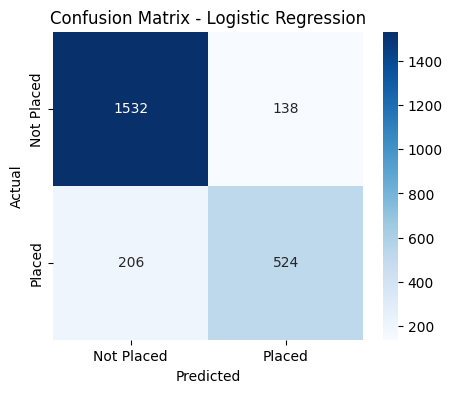

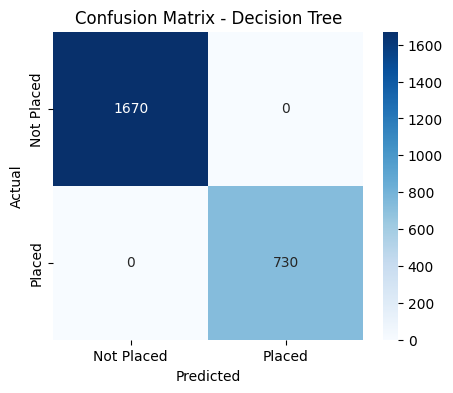

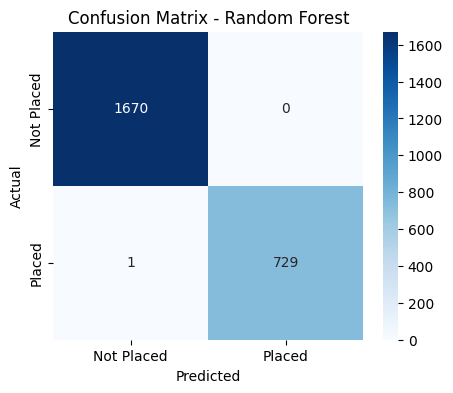

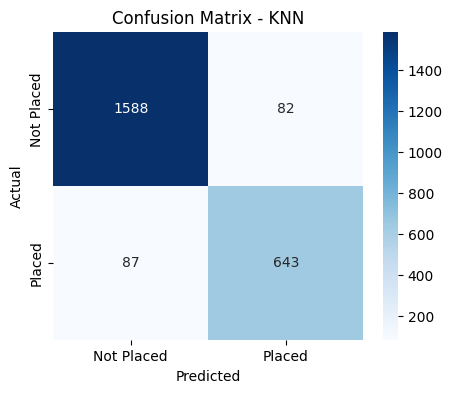

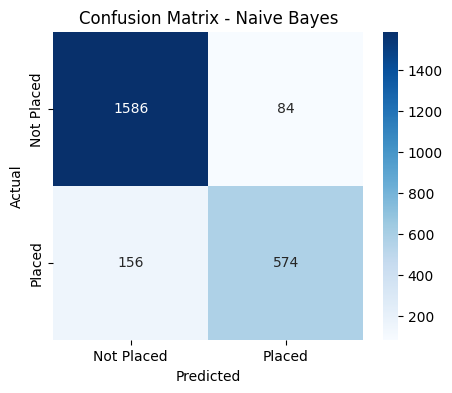

In [17]:
for name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Placed", "Placed"],
        yticklabels=["Not Placed", "Placed"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [18]:
for name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Not Placed",
                "Placed"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  Not Placed       0.88      0.92      0.90      1670
      Placed       0.79      0.72      0.75       730

    accuracy                           0.86      2400
   macro avg       0.84      0.82      0.83      2400
weighted avg       0.85      0.86      0.85      2400

Decision Tree
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00      1670
      Placed       1.00      1.00      1.00       730

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400

Random Forest
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00      1670
      Placed       1.00      1.00      1.00       730

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00   

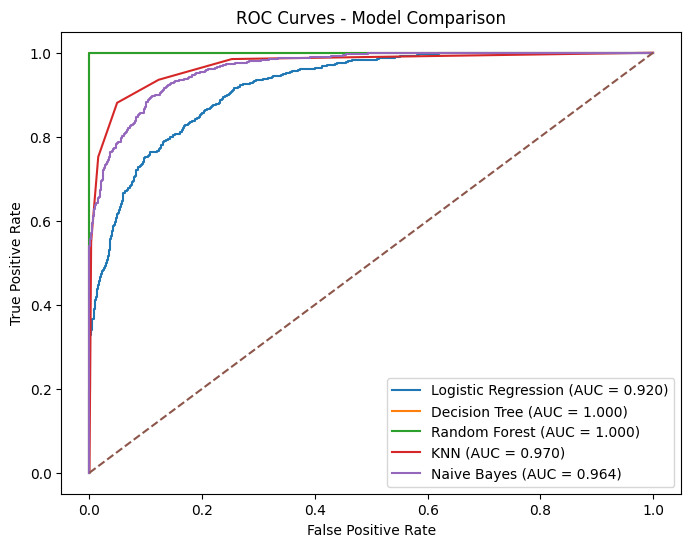

In [19]:
plt.figure(figsize=(8, 6))

for name, pipeline in trained_models.items():

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - Model Comparison")

plt.legend()

plt.show()

In [20]:
cv_results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1 Score": scores.mean(),
        "Std F1 Score": scores.std()
    })

cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    by="Mean F1 Score",
    ascending=False
)

cv_results_df

,Model,Mean F1 Score,Std F1 Score
1,Decision Tree,1.000000,0.000000
2,Random Forest,0.999863,0.000274
3,KNN,0.882699,0.011018
4,Naive Bayes,0.832121,0.010514
0,Logistic Regression,0.736421,0.008957


In [21]:
cv_results_percentage = cv_results_df.copy()

cv_results_percentage["Mean F1 Score"] = (
    cv_results_percentage["Mean F1 Score"] * 100
).round(2)

cv_results_percentage["Std F1 Score"] = (
    cv_results_percentage["Std F1 Score"] * 100
).round(2)

cv_results_percentage

,Model,Mean F1 Score,Std F1 Score
1,Decision Tree,100.00,0.00
2,Random Forest,99.99,0.03
3,KNN,88.27,1.10
4,Naive Bayes,83.21,1.05
0,Logistic Regression,73.64,0.90


In [22]:
rf_pipeline = trained_models["Random Forest"]

rf_model = rf_pipeline.named_steps["model"]

rf_preprocessor = rf_pipeline.named_steps[
    "preprocessor"
]

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
17,numerical__coding_skills,0.367083
19,numerical__aptitude_score,0.176613
13,numerical__cgpa,0.163115
21,numerical__overall_skill_score,0.161838
22,numerical__academic_performance_index,0.071110
18,numerical__communication_skills,0.010057
14,numerical__backlogs,0.009069
23,numerical__profile_strength,0.006925
20,numerical__projects,0.005047
16,numerical__certifications,0.004948


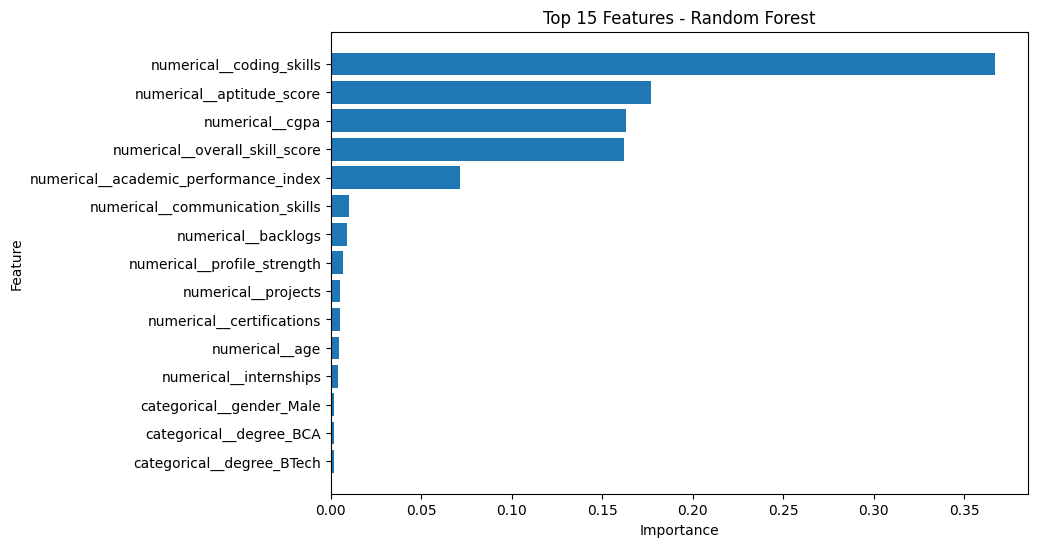

In [23]:
top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features - Random Forest"
)

plt.show()

In [24]:
best_model_name = evaluation_df[
    "F1 Score"
].idxmax()

best_model = trained_models[
    best_model_name
]

print("Final Model Selected:")
print(best_model_name)

print("\nPerformance:")

print(
    evaluation_percentage.loc[
        best_model_name
    ]
)

Final Model Selected:
Decision Tree

Performance:
Accuracy     100.0
Precision    100.0
Recall       100.0
F1 Score     100.0
ROC-AUC      100.0
Name: Decision Tree, dtype: float64


In [25]:
final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_auc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test)[:, 1]
)

print("FINAL MODEL PERFORMANCE")
print("-" * 40)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

FINAL MODEL PERFORMANCE
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


In [26]:
os.makedirs(
    "../models",
    exist_ok=True
)

print("Models directory ready.")

Models directory ready.


In [27]:
# Deployment is trained by 05_Model_Training's calibrated-model section.
# Do not save `best_model` here: it may be the overconfident Decision Tree.
model_path = "../models/placement_prediction_model.pkl"
print("Deployment model is managed by models/train_placement_model.py")
print("Location:", model_path)

Final model saved successfully!
Location: ../models/placement_prediction_model.pkl


In [28]:
loaded_model = joblib.load(
    "../models/placement_prediction_model.pkl"
)

test_predictions = loaded_model.predict(
    X_test.head(10)
)

print("Sample Predictions:")
print(test_predictions)

Sample Predictions:
[0 0 0 1 0 1 1 0 0 0]


In [29]:
sample_student = pd.DataFrame({
    "gender": ["Male"],
    "age": [21],
    "degree": ["BTech"],
    "branch": ["CS"],
    "cgpa": [8.2],
    "backlogs": [0],
    "internships": [2],
    "certifications": [3],
    "coding_skills": [8],
    "communication_skills": [8],
    "aptitude_score": [82],
    "projects": [3],
    "overall_skill_score": [
        (8 + 8 + 82) / 3
    ],
    "academic_performance_index": [
        (8.2 * 10) - (0 * 5)
    ],
    "profile_strength": [
        2 + 3 + 3
    ]
})

sample_student

,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,aptitude_score,projects,overall_skill_score,academic_performance_index,profile_strength
0,Male,21,BTech,CS,8.2,0,2,3,8,8,82,3,32.666667,82.0,8


In [30]:
prediction = loaded_model.predict(
    sample_student
)[0]

probability = loaded_model.predict_proba(
    sample_student
)[0][1]

if prediction == 1:
    result = "Placed"
else:
    result = "Not Placed"

print("Prediction:", result)
print(f"Placement Probability: {probability * 100:.2f}%")

Prediction: Placed
Placement Probability: 100.00%


In [31]:
sample_student = pd.DataFrame({
    "gender": ["Male"],
    "age": [22],
    "degree": ["BTech"],
    "branch": ["Mechanical"],
    "cgpa": [6.2],
    "backlogs": [2],
    "internships": [1],
    "certifications": [1],
    "coding_skills": [4],
    "communication_skills": [5],
    "aptitude_score": [55],
    "projects": [2],
    "overall_skill_score": [21.33],
    "academic_performance_index": [52.0],
    "profile_strength": [4]
})

prediction = loaded_model.predict(sample_student)[0]
probability = loaded_model.predict_proba(sample_student)[0][1]

result = "Placed" if prediction == 1 else "Not Placed"

print("Prediction:", result)
print(f"Placement Probability: {probability * 100:.2f}%")

Prediction: Not Placed
Placement Probability: 0.00%
